===================================== Domaine :  gastrointestinal / Infectious =====================================

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb

In [2]:
df = pd.read_csv("Diseases_and_Symptoms_dataset.csv")

disease_col = "diseases"
symptom_cols = [c for c in df.columns if c != disease_col]

In [3]:
# Filter GI diseases
gi_diseases = [
    'acute pancreatitis', 'infectious gastroenteritis', 'hiatal hernia',
    'gastrointestinal hemorrhage', 'noninfectious gastroenteritis',
    'cholecystitis', 'hemorrhoids', 'liver disease',
    'chronic constipation', 'esophagitis',
    'diverticulitis', 'appendicitis', 'gallstone'
]

df_gi = df[df[disease_col].isin(gi_diseases)].copy()
print("GI dataset shape:", df_gi.shape)

GI dataset shape: (13761, 231)


In [4]:
selected_symptoms = df_gi[symptom_cols].sum()[lambda x: x > 0].index.tolist()
print("Number of selected symptoms:", len(selected_symptoms))

X = df_gi[selected_symptoms]
y = df_gi[disease_col]


Number of selected symptoms: 45


In [5]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("Disease classes:", le.classes_)

Disease classes: ['acute pancreatitis' 'appendicitis' 'cholecystitis'
 'chronic constipation' 'diverticulitis' 'esophagitis' 'gallstone'
 'gastrointestinal hemorrhage' 'hemorrhoids' 'hiatal hernia'
 'infectious gastroenteritis' 'liver disease'
 'noninfectious gastroenteritis']


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [7]:
# Models
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        class_weight="balanced",
        random_state=42
    ),

    "XGBoost": xgb.XGBClassifier(
        n_estimators=500,
        learning_rate=0.3,
        random_state=42,
        eval_metric="mlogloss"
    ),

    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        multi_class="ovr"
    )
}


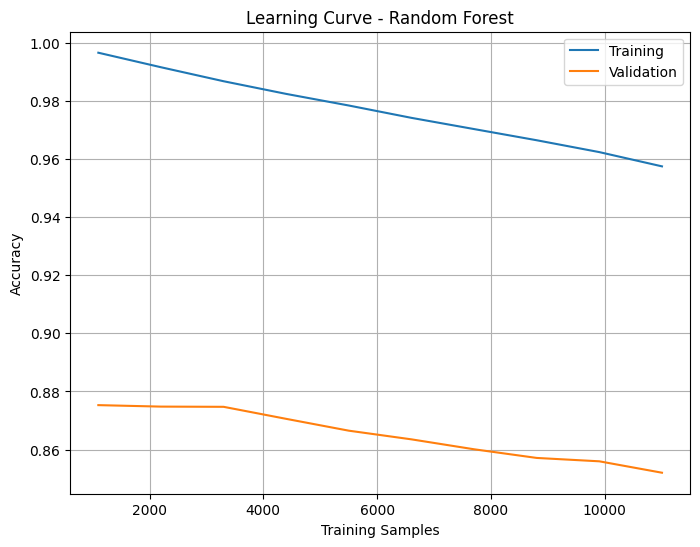

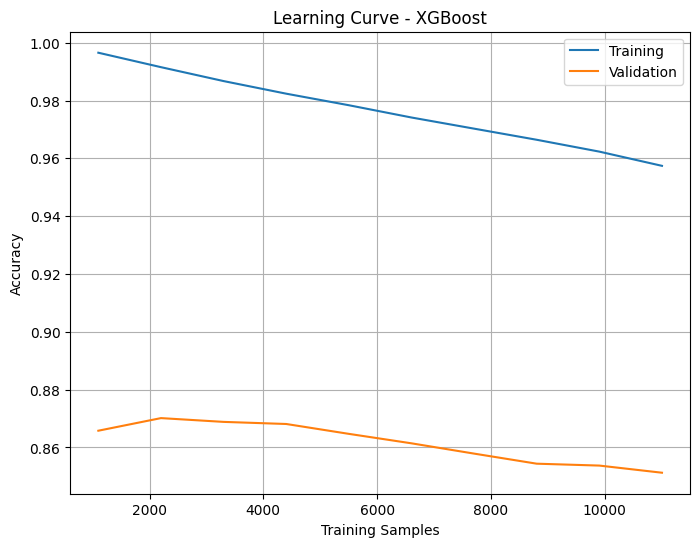

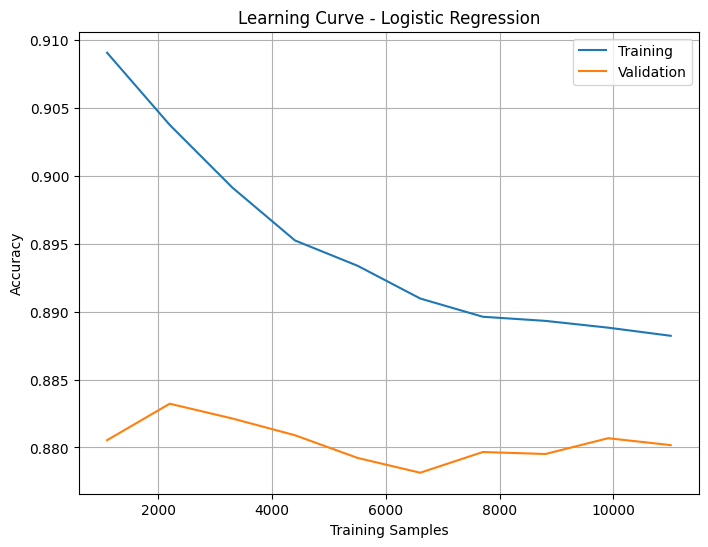

In [9]:
def plot_learning_curve(model, X, y, name):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y,
        cv=5,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring="accuracy",
        n_jobs=-1,
        shuffle=True,
        random_state=42
    )

    plt.figure(figsize=(8,6))
    plt.plot(train_sizes, train_scores.mean(axis=1), label="Training")
    plt.plot(train_sizes, val_scores.mean(axis=1), label="Validation")
    plt.title(f"Learning Curve - {name}")
    plt.xlabel("Training Samples")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid()
    plt.show()


for name, model in models.items():
    plot_learning_curve(model, X, y_encoded, name)


In [10]:
# Train models & evaluate
results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"{name} Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=le.classes_))



Training Random Forest...
Random Forest Accuracy: 0.8402
                               precision    recall  f1-score   support

           acute pancreatitis       0.88      0.89      0.89       241
                 appendicitis       0.83      0.78      0.80       162
                cholecystitis       0.83      0.74      0.78       241
         chronic constipation       0.94      0.93      0.94       165
               diverticulitis       0.83      0.86      0.85       243
                  esophagitis       0.94      0.96      0.95       243
                    gallstone       0.63      0.72      0.67       162
  gastrointestinal hemorrhage       0.96      0.97      0.97       243
                  hemorrhoids       0.99      0.96      0.97       164
                hiatal hernia       0.94      0.94      0.94       163
   infectious gastroenteritis       0.60      0.66      0.63       243
                liver disease       0.98      0.99      0.99       242
noninfectious gast

c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1273: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression Accuracy: 0.8761
                               precision    recall  f1-score   support

           acute pancreatitis       0.90      0.91      0.90       241
                 appendicitis       0.84      0.83      0.84       162
                cholecystitis       0.95      0.73      0.82       241
         chronic constipation       0.92      0.96      0.94       165
               diverticulitis       0.84      0.91      0.88       243
                  esophagitis       0.98      0.96      0.97       243
                    gallstone       0.62      0.90      0.74       162
  gastrointestinal hemorrhage       1.00      0.96      0.98       243
                  hemorrhoids       0.99      0.96      0.98       164
                hiatal hernia       0.94      0.95      0.95       163
   infectious gastroenteritis       0.73      0.73      0.73       243
                liver disease       0.99      0.99      0.99       242
noninfectious gastroenteritis       0.7

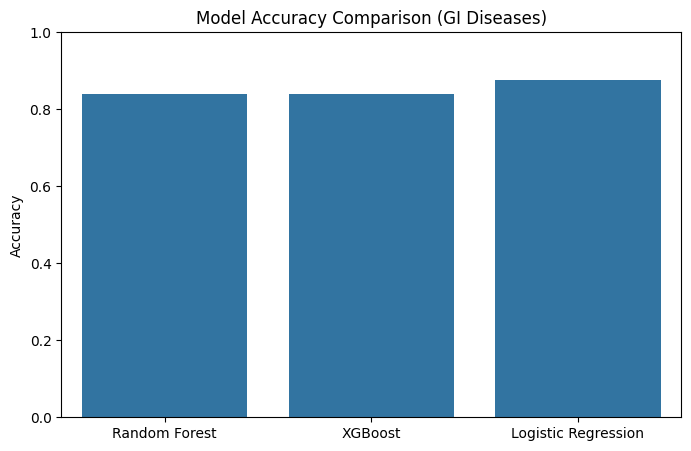

In [11]:
#  Accuracy comparison
plt.figure(figsize=(8,5))
sns.barplot(x=list(results.keys()), y=list(results.values()))
plt.title("Model Accuracy Comparison (GI Diseases)")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.show()

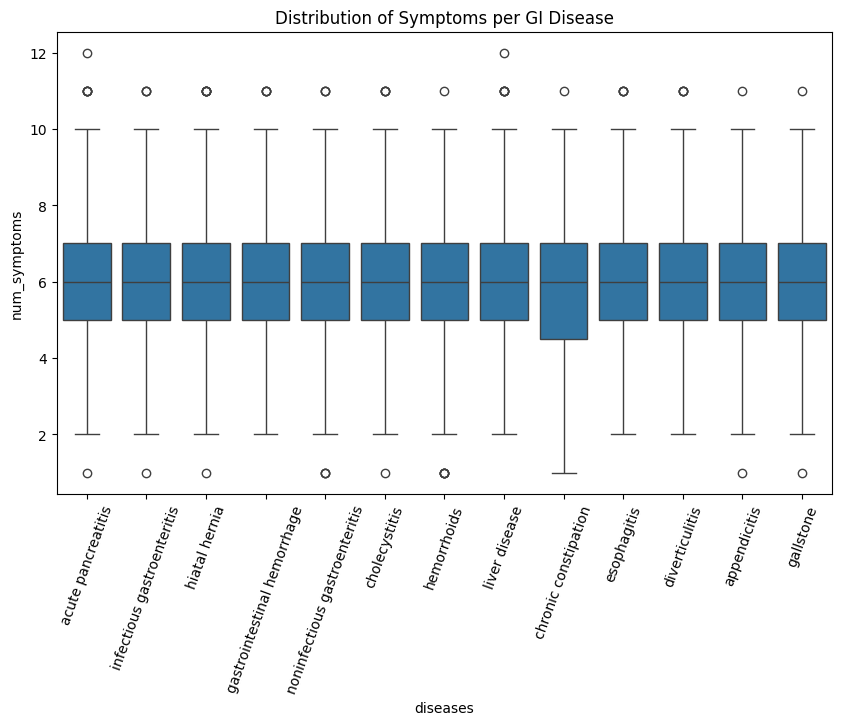

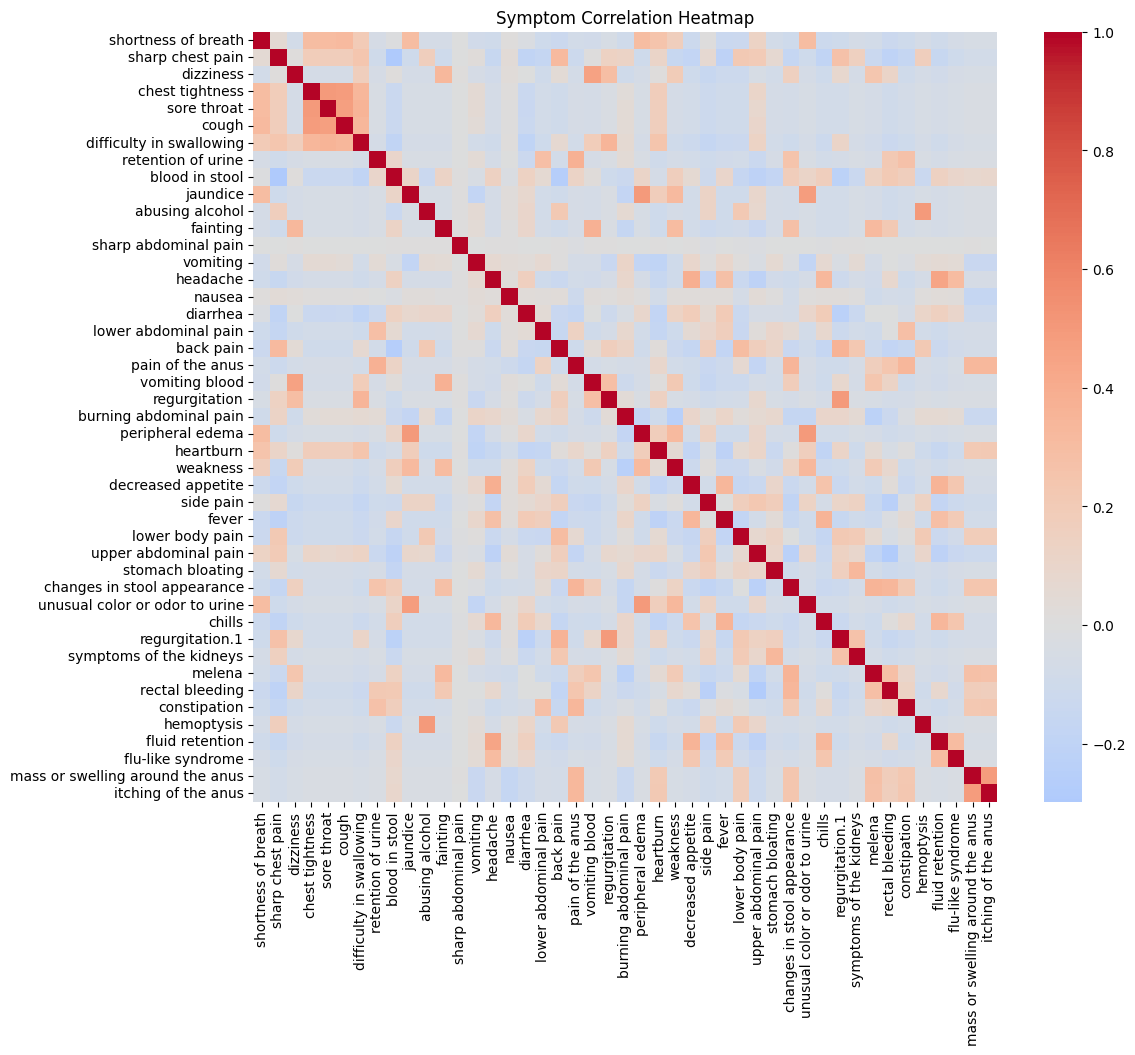

In [12]:
# Data analysis & visualization

df_gi["num_symptoms"] = df_gi[selected_symptoms].sum(axis=1)

plt.figure(figsize=(10,6))
sns.boxplot(x="diseases", y="num_symptoms", data=df_gi)
plt.xticks(rotation=70)
plt.title("Distribution of Symptoms per GI Disease")
plt.show()

# Symptom correlation
plt.figure(figsize=(12,10))
sns.heatmap(df_gi[selected_symptoms].corr(), cmap="coolwarm", center=0)
plt.title("Symptom Correlation Heatmap")
plt.show()


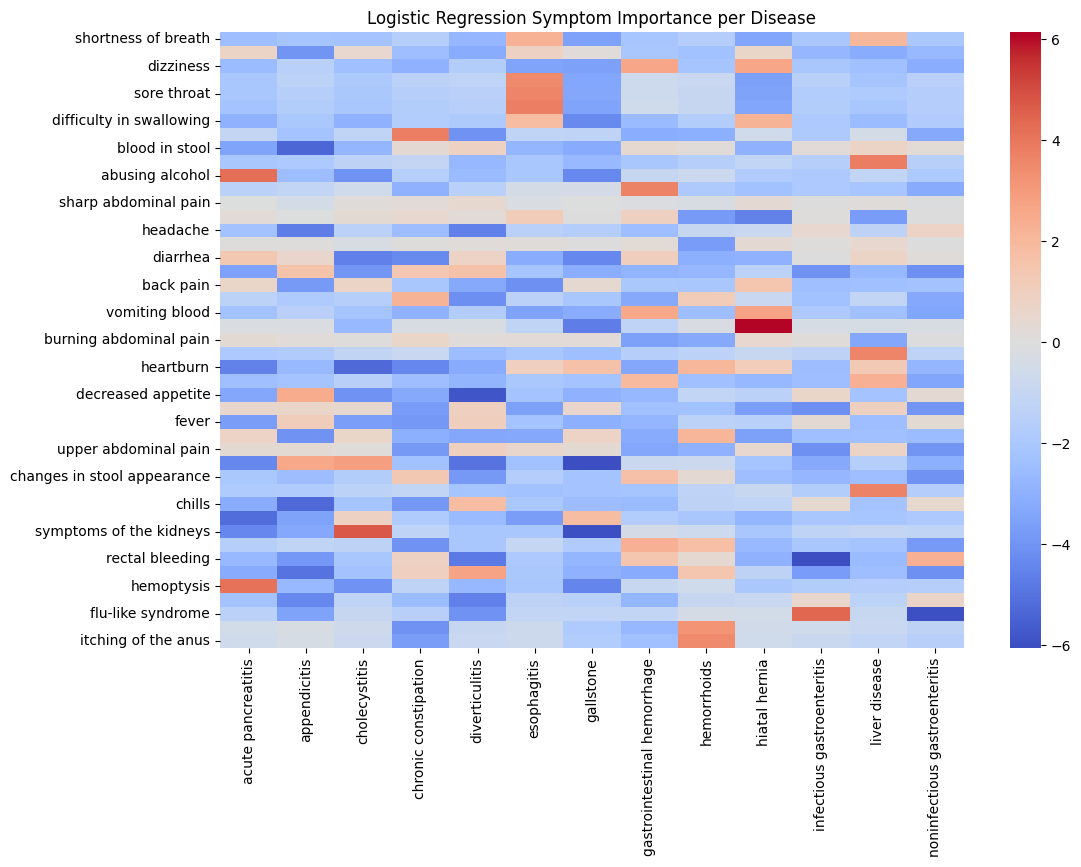

In [13]:

# Logistic Regression feature importance
lr = models["Logistic Regression"]

coef_df = pd.DataFrame(
    lr.coef_.T,
    index=selected_symptoms,
    columns=le.classes_
)

plt.figure(figsize=(12,8))
sns.heatmap(coef_df, cmap="coolwarm", center=0)
plt.title("Logistic Regression Symptom Importance per Disease")
plt.show()
